# Summative Assignment: Linear Regression Task

## Mission & Problem
My mission is to create jobs for Rwandan and African youth by 2035 through software engineering applications — building tools/models that enable job creation (e.g., predictive analytics for youth employment gaps, skill-job matching apps, or policy dashboards), not just software jobs themselves.  
This model predicts youth unemployment rates (ages 15-24) to identify trends/factors, informing targeted interventions like digital skills programs or entrepreneurship platforms in Africa/Rwanda.

## Dataset
**Name**: Youth unemployment rate (% of total labor force ages 15-24) – modeled ILO estimate  
**Source**: World Bank Open Data https://api.worldbank.org/v2/en/indicator/SL.UEM.1524.ZS?downloadformat=csv  
**Description**: Annual youth unemployment rates across countries and years (1991–latest available), sourced from ILO estimates. Used here to predict youth unemployment and support mission-driven tools for job creation in Africa/Rwanda.

In [7]:
# ────────────────────────────────────────────────
# Imports
# ────────────────────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import pickle
from scipy.optimize import minimize

In [ ]:
# ────────────────────────────────────────────────
# Load World Bank youth unemployment CSV – Raw state
# ────────────────────────────────────────────────

# Skip the first 4 metadata rows so pandas can parse the table
df_raw = pd.read_csv('API_SL.UEM.1524.ZS_DS2_en_csv_v2_1984.csv', skiprows=4)

print("=== RAW DATASET – BEFORE ANY FURTHER CLEANING ===")
print("Shape (wide format with year columns):", df_raw.shape)
print("\nColumns (should include Country Name, Country Code, then years):", df_raw.columns.tolist()[:15], "...")  
print("\nFirst 5 rows:\n", df_raw.head())
print("\nInfo (raw):\n")
df_raw.info()
print("\nMissing values (raw):\n", df_raw.isnull().sum().head(15))  
print("\nUnique values in 'Country Name' column:\n", df_raw['Country Name'].unique()[:10])

=== RAW DATASET – BEFORE ANY FURTHER CLEANING ===
Shape (wide format with year columns): (266, 71)

Columns (should include Country Name, Country Code, then years): ['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code', '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970'] ...

First 5 rows:
                   Country Name Country Code  \
0                        Aruba          ABW   
1  Africa Eastern and Southern          AFE   
2                  Afghanistan          AFG   
3   Africa Western and Central          AFW   
4                       Angola          AGO   

                                      Indicator Name  Indicator Code  1960  \
0  Unemployment, youth total (% of total labor fo...  SL.UEM.1524.ZS   NaN   
1  Unemployment, youth total (% of total labor fo...  SL.UEM.1524.ZS   NaN   
2  Unemployment, youth total (% of total labor fo...  SL.UEM.1524.ZS   NaN   
3  Unemployment, youth total (% of total labor fo...  SL.UEM.15

In [9]:
# ─────────────────────────────────────────────────
# Clean World Bank youth unemployment CSV + FILTER TO AFRICA/RWANDA/SUB-SAHARAN/EASTERN AFRICA
# (detected from dataset: aggregates + individual African countries present in World Bank data)
# ─────────────────────────────────────────────────

# Skip the first 4 metadata rows
df_cleaned = pd.read_csv('API_SL.UEM.1524.ZS_DS2_en_csv_v2_1984.csv', skiprows=4)

# Drop unnecessary metadata columns
drop_cols = ['Indicator Name', 'Indicator Code', 'Unnamed: 67']
df_cleaned = df_cleaned.drop(columns=[c for c in drop_cols if c in df_cleaned.columns], errors='ignore')

# Melt wide years into long format
df_long = pd.melt(
    df_cleaned,
    id_vars=['Country Name', 'Country Code'],
    var_name='Year',
    value_name='YouthUnemploymentRate'
)

# Clean types and remove rows with missing target
df_long['Year'] = pd.to_numeric(df_long['Year'], errors='coerce')
df_long = df_long.dropna(subset=['YouthUnemploymentRate', 'Year'])

# Final clean dataframe (before mission filter)
df_temp = df_long[['Country Name', 'Year', 'YouthUnemploymentRate']].rename(
    columns={'Country Name': 'Country'}
)

# ─── MISSION-SPECIFIC FILTER (Africa/Rwanda/Sub-Saharan/Eastern Africa) ───
# Detected African countries/regions directly from World Bank dataset names
african_countries = [
    'Africa Eastern and Southern', 'Africa Western and Central',
    'Rwanda',
    'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi', 'Cameroon',
    'Central African Republic', 'Chad', 'Comoros', 'Congo, Dem. Rep.', 'Congo, Rep.',
    'Cote d\'Ivoire', 'Djibouti', 'Equatorial Guinea', 'Eritrea', 'Eswatini',
    'Ethiopia', 'Gabon', 'Gambia, The', 'Ghana', 'Guinea', 'Guinea-Bissau', 'Kenya',
    'Lesotho', 'Liberia', 'Madagascar', 'Malawi', 'Mali', 'Mauritania', 'Mauritius',
    'Mozambique', 'Namibia', 'Niger', 'Nigeria', 'Sao Tome and Principe', 'Senegal',
    'Seychelles', 'Sierra Leone', 'Somalia', 'South Africa', 'South Sudan', 'Sudan',
    'Tanzania', 'Togo', 'Uganda', 'Zambia', 'Zimbabwe',
    'Algeria', 'Egypt, Arab Rep.', 'Libya', 'Morocco', 'Tunisia'
]

df = df_temp[df_temp['Country'].isin(african_countries)].copy()

print("=== CLEANED + AFRICA-FILTERED DATASET (mission-specific for Rwanda/African youth job creation) ===")
print("Final shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:\n", df.head())
print("\nInfo:\n")
df.info()
print("\nMissing values:\n", df.isnull().sum())
print("\nUnique African countries/regions:", df['Country'].nunique())
print("Year range:", df['Year'].min(), "to", df['Year'].max())
print("\nSample countries:", df['Country'].unique()[:10])

=== CLEANED + AFRICA-FILTERED DATASET (mission-specific for Rwanda/African youth job creation) ===
Final shape: (1850, 3)

Columns: ['Country', 'Year', 'YouthUnemploymentRate']

First 5 rows:
                           Country    Year  YouthUnemploymentRate
8247  Africa Eastern and Southern  1991.0              15.445812
8249   Africa Western and Central  1991.0               7.246403
8250                       Angola  1991.0              39.841000
8262                      Burundi  1991.0               3.893000
8264                        Benin  1991.0               1.746000

Info:

<class 'pandas.core.frame.DataFrame'>
Index: 1850 entries, 8247 to 17555
Data columns (total 3 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Country                1850 non-null   object 
 1   Year                   1850 non-null   float64
 2   YouthUnemploymentRate  1850 non-null   float64
dtypes: float64(2), object(1)
memory usage: 

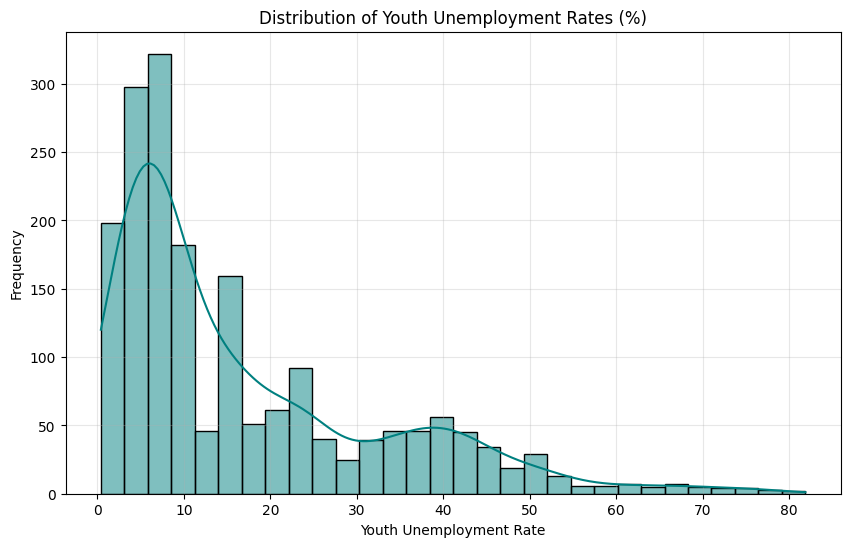

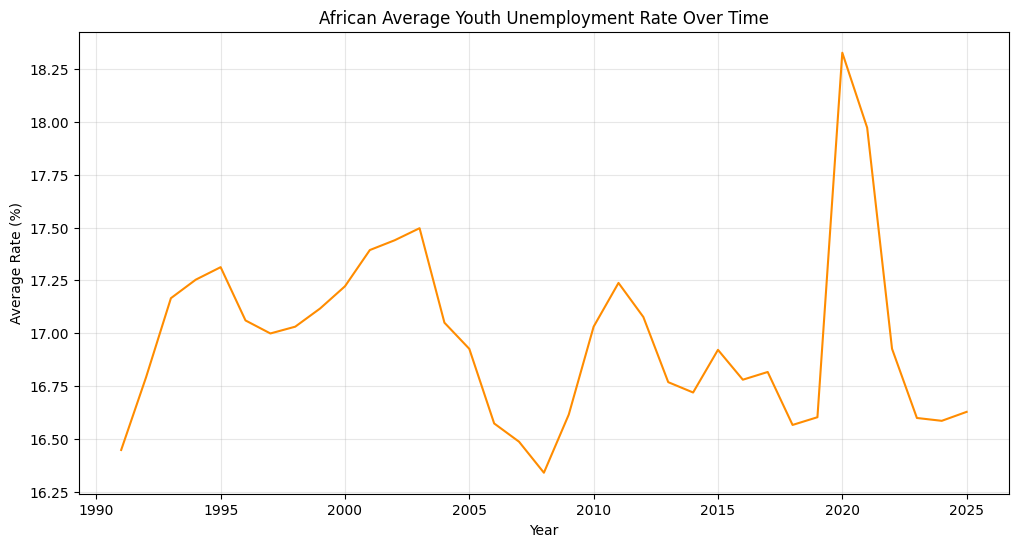

In [10]:
# ────────────────────────────────────────────────
# Visualizations
# ────────────────────────────────────────────────

# Viz 1: Distribution of target
plt.figure(figsize=(10, 6))
sns.histplot(df['YouthUnemploymentRate'].dropna(), kde=True, bins=30, color='teal')
plt.title('Distribution of Youth Unemployment Rates (%)')
plt.xlabel('Youth Unemployment Rate')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.show()

# Viz 2: Trend over time (African average)
year_avg = df.groupby('Year')['YouthUnemploymentRate'].mean().reset_index()
plt.figure(figsize=(12, 6))
sns.lineplot(data=year_avg, x='Year', y='YouthUnemploymentRate', color='darkorange')
plt.title('African Average Youth Unemployment Rate Over Time')
plt.xlabel('Year')
plt.ylabel('Average Rate (%)')
plt.grid(True, alpha=0.3)
plt.show()

In [11]:
# ────────────────────────────────────────────────
# Feature Engineering & Preprocessing
# ────────────────────────────────────────────────

df_clean = df.dropna(subset=['YouthUnemploymentRate'])

# Features & target
X_multi = df_clean[['Year', 'Country']]
y = df_clean['YouthUnemploymentRate']

# Column transformer: One-hot Country, scale Year
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ['Country']),
        ('num', StandardScaler(), ['Year'])
    ])

# Split data
X_train_m, X_test_m, y_train, y_test = train_test_split(
    X_multi, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train_m.shape, y_train.shape)
print("Test shape:", X_test_m.shape, y_test.shape)

print("\nPreprocessing complete. Ready for modeling.")

Train shape: (1480, 2) (1480,)
Test shape: (370, 2) (370,)

Preprocessing complete. Ready for modeling.


In [12]:
# ────────────────────────────────────────────────
# Model 1 – Linear Regression: y = m * x + b
# Optimized with scipy.optimize.minimize (L-BFGS-B)
# Using only 'Year' feature
# ────────────────────────────────────────────────

X_lr = df[['Year']].values.astype(float)
y_lr = df['YouthUnemploymentRate'].values

# Remove any rows where target is NaN
mask = ~np.isnan(y_lr)
X_lr = X_lr[mask]
y_lr = y_lr[mask]

X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_lr, y_lr, test_size=0.2, random_state=42
)

scaler_lr = StandardScaler()
X_train_lr_s = scaler_lr.fit_transform(X_train_lr)
X_test_lr_s  = scaler_lr.transform(X_test_lr)

# ─── Loss function ───
def mse_loss(params, X, y):
    m, b = params
    predictions = m * X + b
    return np.mean((predictions - y) ** 2)

# ─── Callback for loss history ───
loss_history_train = []
loss_history_test  = []

def callback(params):
    train_loss = mse_loss(params, X_train_lr_s, y_train_lr)
    test_loss  = mse_loss(params, X_test_lr_s, y_test_lr)
    loss_history_train.append(train_loss)
    loss_history_test.append(test_loss)

# Better initial guess
from sklearn.linear_model import LinearRegression
quick_lr = LinearRegression().fit(X_train_lr_s, y_train_lr)
initial_m = quick_lr.coef_[0]
initial_b = quick_lr.intercept_
initial_params = np.array([initial_m, initial_b])

print("Initial guess from quick fit: m =", initial_m, "b =", initial_b)

# Optimize
result = minimize(
    mse_loss,
    initial_params,
    args=(X_train_lr_s, y_train_lr),
    method='L-BFGS-B',
    callback=callback,
    options={
        'maxiter': 1000,
        'gtol': 1e-8,
        'norm': np.inf,
        'disp': True
    }
)

m_opt, b_opt = result.x

print("\nOptimized parameters:")
print(f"  m (slope): {m_opt:.6f}")
print(f"  b (intercept): {b_opt:.4f}")
print(f"  Success: {result.success}")
print(f"  Message: {result.message}")

# Predictions
y_pred_train_lr = m_opt * X_train_lr_s + b_opt
y_pred_test_lr  = m_opt * X_test_lr_s  + b_opt

if np.isnan(y_pred_train_lr).any() or np.isnan(y_pred_test_lr).any():
    print("Warning: NaN detected in predictions! Optimization failed.")
else:
    print("Linear Regression:")
    print(f"Train MSE: {mean_squared_error(y_train_lr, y_pred_train_lr):.4f}")
    print(f"Test MSE:  {mean_squared_error(y_test_lr, y_pred_test_lr):.4f}")
    print(f"R²:        {r2_score(y_test_lr, y_pred_test_lr):.4f}\n")

Initial guess from quick fit: m = -0.1431495426445122 b = 16.72813684336887

Optimized parameters:
  m (slope): -0.000006
  b (intercept): 16.7281
  Success: True
  Message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
Linear Regression:
Train MSE: 241.8194
Test MSE:  277.2877
R²:        -0.0058



/tmp/ipykernel_210/3794921458.py:49: OptimizeWarning: Unknown solver options: norm
  result = minimize(
/tmp/ipykernel_210/3794921458.py:49: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  result = minimize(


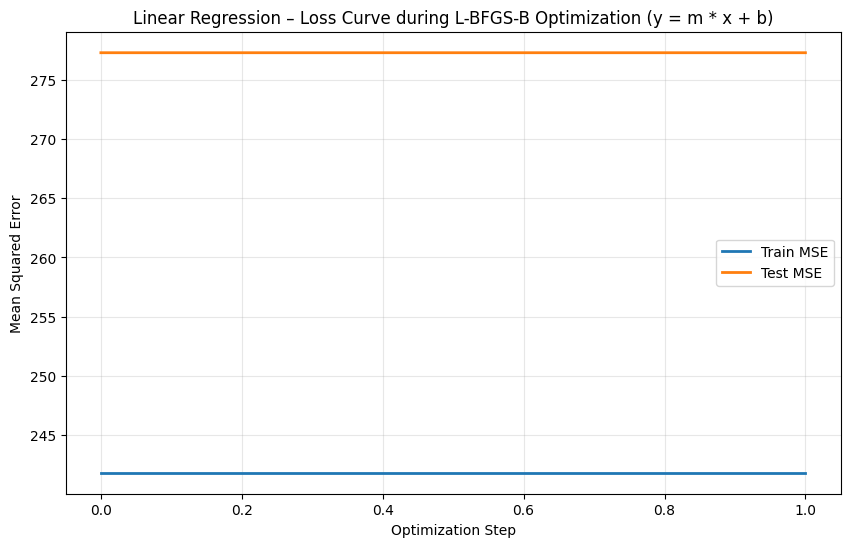

In [13]:
# Loss curve – Linear Regression
plt.figure(figsize=(10, 6))
plt.plot(loss_history_train, label='Train MSE', linewidth=2)
plt.plot(loss_history_test,  label='Test MSE',  linewidth=2)
plt.title('Linear Regression – Loss Curve during L-BFGS-B Optimization (y = m * x + b)')
plt.xlabel('Optimization Step')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

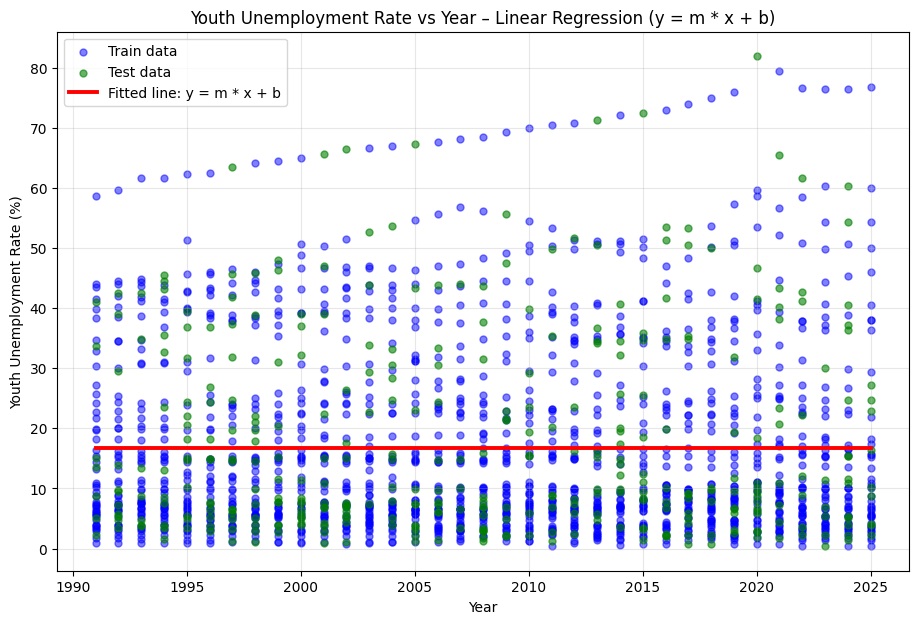

In [14]:
# Scatter plot + fitted line: y = m * x + b
plt.figure(figsize=(11, 7))

plt.scatter(X_train_lr, y_train_lr, color='blue', alpha=0.5, s=25, label='Train data')
plt.scatter(X_test_lr,  y_test_lr,  color='green', alpha=0.6, s=25, label='Test data')

# Fitted line
x_range = np.linspace(X_lr.min(), X_lr.max(), 300).reshape(-1,1)
x_range_scaled = scaler_lr.transform(x_range)
y_fit = m_opt * x_range_scaled + b_opt

plt.plot(x_range, y_fit, color='red', linewidth=2.8, label='Fitted line: y = m * x + b')
plt.title('Youth Unemployment Rate vs Year – Linear Regression (y = m * x + b)')
plt.xlabel('Year')
plt.ylabel('Youth Unemployment Rate (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [15]:
# ────────────────────────────────────────────────
# Model 2 – Decision Tree Regressor
# ────────────────────────────────────────────────

dt_model = DecisionTreeRegressor(random_state=42)
dt_pipe = Pipeline([('prep', preprocessor), ('model', dt_model)])
dt_pipe.fit(X_train_m, y_train)

y_pred_train_dt = dt_pipe.predict(X_train_m)
y_pred_test_dt  = dt_pipe.predict(X_test_m)

print("Decision Tree:")
print(f"Train MSE: {mean_squared_error(y_train, y_pred_train_dt):.4f}")
print(f"Test MSE:  {mean_squared_error(y_test,  y_pred_test_dt):.4f}")
print(f"R²:        {r2_score(y_test, y_pred_test_dt):.4f}\n")

Decision Tree:
Train MSE: 0.0000
Test MSE:  2.1965
R²:        0.9920



In [16]:
# ────────────────────────────────────────────────
# Model 3 – Random Forest Regressor
# ────────────────────────────────────────────────

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_pipe = Pipeline([('prep', preprocessor), ('model', rf_model)])
rf_pipe.fit(X_train_m, y_train)

y_pred_train_rf = rf_pipe.predict(X_train_m)
y_pred_test_rf  = rf_pipe.predict(X_test_m)

print("Random Forest:")
print(f"Train MSE: {mean_squared_error(y_train, y_pred_train_rf):.4f}")
print(f"Test MSE:  {mean_squared_error(y_test,  y_pred_test_rf):.4f}")
print(f"R²:        {r2_score(y_test, y_pred_test_rf):.4f}\n")

Random Forest:
Train MSE: 0.1940
Test MSE:  1.7844
R²:        0.9935



In [ ]:
# ────────────────────────────────────────────────
# Save the BEST-performing model
# ────────────────────────────────────────────────

best_pipe = rf_pipe
best_model_name = "RandomForestRegressor"

with open('best_youth_unemployment_model.pkl', 'wb') as f:
    pickle.dump(best_pipe, f)

print(f"Best model saved: {best_model_name}")

Best model saved: RandomForestRegressor


In [18]:
# ────────────────────────────────────────────────
# Single data point prediction
# ────────────────────────────────────────────────

model = pickle.load(open('best_youth_unemployment_model.pkl', 'rb'))

# Example prediction for Rwanda in 2030
new_data = pd.DataFrame({'Year': [2030], 'Country': ['Rwanda']})
pred = model.predict(new_data)
print(f"Predicted Youth Unemployment Rate in Rwanda (2030): {pred[0]:.2f}%")

Predicted Youth Unemployment Rate in Rwanda (2030): 16.77%
